# Analyse approfondie — Segments à fort volume et fréquence élevée

L'[analyse globale](analyse_globale.ipynb) a permis de repérer les premiers écarts.
Ici, je cherche les groupes qui combinent beaucoup de contrats et une fréquence élevée,
puis je croise quelques variables pour comprendre ce qui se cache derrière leurs moyennes.

Ce notebook peut être exécuté seul. Il reprend la même préparation et les mêmes tranches que l'analyse globale.
Les résultats restent descriptifs : un croisement ne suffit pas à démontrer une cause.

## 1. Préparer les données et les repères

Je relis les deux fichiers bruts, je mets les six contrats orphelins de côté et je conserve tous les contrats de `freq`.
Le nombre de sinistres déclaré vient de `ClaimNb`. Les montants non retrouvés restent inconnus.

In [1]:
from pathlib import Path

# Retrouver le dossier du projet depuis la racine ou depuis notebook.
racine = Path.cwd()
if racine.name == 'notebook':
    racine = racine.parent

import pandas as pd
import numpy as np

colonnes_freq = [
    'IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge',
    'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'
]

# 14 lignes de description dans freq, 4 dans sev.
# quotechar retire les apostrophes autour des catégories.
df_freq = pd.read_csv(
    racine / 'data/raw/freMTPL2freq.arff', skiprows=14, names=colonnes_freq,
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)
df_sev = pd.read_csv(
    racine / 'data/raw/freMTPL2sev.arff', skiprows=4, names=['IDpol', 'ClaimAmount'],
    quotechar="'", na_values='?', dtype={'IDpol': 'int64'}
)

import matplotlib.pyplot as plt

In [2]:
# Mettre de côté les sinistres dont le contrat est absent de freq.
orphelins = ~df_sev['IDpol'].isin(df_freq['IDpol'])
df_sev_orphelins = df_sev.loc[orphelins].copy()
df_sev_rapprochable = df_sev.loc[~orphelins].copy()

# Regrouper les sinistres pour avoir une ligne par contrat.
df_agg_sev = (
    df_sev_rapprochable.groupby('IDpol', as_index=False)
        .agg(
            NbSinister=('IDpol', 'count'),
            TotalAmount=('ClaimAmount', 'sum')
        )
)

# Garder tous les contrats de freq.
# validate vérifie qu'il y a une seule ligne par IDpol de chaque côté.
df_unified = pd.merge(
    df_freq, df_agg_sev, on='IDpol', how='left', validate='one_to_one'
)

# Conditions pour distinguer les situations après la jointure.
is_na = df_unified['NbSinister'].isna()
has_claim = df_unified['ClaimNb'] > 0
same_count = df_unified['ClaimNb'] == df_unified['NbSinister']

df_unified['Status'] = np.select(
    [is_na & has_claim,
     is_na & ~has_claim,
     ~is_na & has_claim & same_count,
     ~is_na & has_claim & ~same_count],
    ['Montant non retrouvé', 'Sans sinistre',
     'Nombre concordant', 'Nombre différent'],
    default='À vérifier'
)

# Contrôles de la table obtenue.
print("Nombre de contrats :", len(df_unified))
print("IDpol répétés :", df_unified['IDpol'].duplicated().sum())
print("Nombre total de sinistres déclaré :", df_unified['ClaimNb'].sum())
print("Exposition conservée :",
      df_unified['Exposure'].sum() == df_freq['Exposure'].sum())
print("Montant rapprochable conservé :",
      round(df_unified['TotalAmount'].sum(), 2)
      == round(df_sev_rapprochable['ClaimAmount'].sum(), 2))
print(df_unified['Status'].value_counts())

print("Contrats avec un nombre de sinistres différent :")
print(df_unified.loc[
    df_unified['Status'] == 'Nombre différent',
    ['IDpol', 'ClaimNb', 'NbSinister']
].to_string(index=False))

print("Contrats orphelins mis de côté :", df_sev_orphelins['IDpol'].nunique())
print("Lignes de sinistres mises de côté :", len(df_sev_orphelins))

Nombre de contrats : 678013
IDpol répétés : 0
Nombre total de sinistres déclaré : 36102
Exposition conservée : True
Montant rapprochable conservé : True
Status
Sans sinistre           643953
Nombre concordant        24943
Montant non retrouvé      9116
Nombre différent             1
Name: count, dtype: int64
Contrats avec un nombre de sinistres différent :
  IDpol  ClaimNb  NbSinister
4158255        2         1.0
Contrats orphelins mis de côté : 6
Lignes de sinistres mises de côté : 195


Je recalcule les KPI pour garder les mêmes repères : **678 013 contrats**, **36 102 sinistres déclarés**
et une fréquence de **10,07 sinistres pour 100 années d'exposition**.
Les montants concernent seulement les sinistres rapprochés.

In [3]:
# Calculer les totaux du portefeuille.
nb_contrats = len(df_unified)
exposition_totale = df_unified['Exposure'].sum()
nb_sinistres_declares = df_unified['ClaimNb'].sum()
nb_sinistres_observes = df_unified['NbSinister'].sum()

# Additionner les montants disponibles, sans remplacer les NaN par zéro.
# min_count=1 garde un résultat NaN si aucun montant n'est disponible.
montant_observe = df_unified['TotalAmount'].sum(min_count=1)

# Calculer les ratios à partir des totaux.
frequence100 = nb_sinistres_declares / exposition_totale * 100
cout_moyen_observe = montant_observe / nb_sinistres_observes
cout_observe_par_annee = montant_observe / exposition_totale

# Mesurer la part des contrats sinistrés sans montant retrouvé.
nb_contrats_sinistres = (df_unified['ClaimNb'] > 0).sum()
nb_contrats_sans_montant = (df_unified['Status'] == 'Montant non retrouvé').sum()
part_sans_montant = nb_contrats_sans_montant / nb_contrats_sinistres * 100

# Une seule ligne pour résumer le portefeuille.
df_kpi = pd.DataFrame({
    'NbContrats': [nb_contrats],
    'ExpositionTotaleAnnees': [exposition_totale],
    'NbSinistresDeclares': [nb_sinistres_declares],
    'NbSinistresObserves': [nb_sinistres_observes],
    'MontantObserveEuros': [montant_observe],
    'FrequencePour100Annees': [frequence100],
    'CoutMoyenObserveEuros': [cout_moyen_observe],
    'CoutObserveParAnneeEuros': [cout_observe_par_annee],
    'PartContratsSinistresSansMontantPct': [part_sans_montant]
})

# .T affiche les KPI verticalement pour faciliter la lecture.
# df_kpi garde une seule ligne et les valeurs non arrondies.
print(df_kpi.round(2).T)

                                               0
NbContrats                             678013.00
ExpositionTotaleAnnees                 358499.45
NbSinistresDeclares                     36102.00
NbSinistresObserves                     26444.00
MontantObserveEuros                  59909216.50
FrequencePour100Annees                     10.07
CoutMoyenObserveEuros                    2265.51
CoutObserveParAnneeEuros                  167.11
PartContratsSinistresSansMontantPct        26.76


Je reprends les tranches de l'analyse globale. Les âges de 100 ans restent identifiés à part.
Les bornes hautes des tranches sont incluses, par exemple 25-34 ans pour les âges entiers supérieurs à 24 et inférieurs ou égaux à 34.

In [4]:
# Garder la table unifiée et créer une copie avec les tranches.
df_segments = df_unified.copy()

df_segments['TrancheAgeConducteur'] = pd.cut(
    df_segments['DrivAge'],
    bins=[17, 24, 34, 44, 54, 64, 74, 99, np.inf],
    labels=['18-24 ans', '25-34 ans', '35-44 ans', '45-54 ans',
            '55-64 ans', '65-74 ans', '75-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheAgeVehicule'] = pd.cut(
    df_segments['VehAge'],
    bins=[-1, 0, 2, 5, 10, 20, 99, np.inf],
    labels=['0 an', '1-2 ans', '3-5 ans', '6-10 ans', '11-20 ans',
            '21-99 ans', '100 ans et plus (à vérifier)']
)

df_segments['TrancheBonusMalus'] = pd.cut(
    df_segments['BonusMalus'],
    bins=[0, 50, 75, 100, 125, 150, 200, np.inf],
    labels=['50 ou moins', '51-75', '76-100', '101-125',
            '126-150', '151-200', '201 et plus']
)

df_segments['TranchePuissance'] = pd.cut(
    df_segments['VehPower'],
    bins=[0, 5, 7, 9, 11, np.inf],
    labels=['5 ou moins', '6-7', '8-9', '10-11', '12 et plus']
)

df_segments['TrancheDensite'] = pd.cut(
    df_segments['Density'],
    bins=[0, 100, 500, 1000, 5000, 20000, np.inf],
    labels=['1-100', '101-500', '501-1 000', '1 001-5 000',
            '5 001-20 000', '20 001 et plus']
)

segments_tranches = [
    'TrancheAgeConducteur', 'TrancheAgeVehicule', 'TrancheBonusMalus',
    'TranchePuissance', 'TrancheDensite'
]

# Chaque contrat doit appartenir à une tranche pour chaque variable.
print("Contrats sans tranche attribuée :")
print(df_segments[segments_tranches].isna().sum())

Contrats sans tranche attribuée :
TrancheAgeConducteur    0
TrancheAgeVehicule      0
TrancheBonusMalus       0
TranchePuissance        0
TrancheDensite          0
dtype: int64


## 2. Choisir les segments à approfondir

Pour cette exploration, je retiens les groupes qui ont :

- au moins **10 000 contrats** ;
- au moins **1 000 années d'exposition** ;
- une fréquence au moins **20 % supérieure à celle du portefeuille**, soit environ **12,08 sinistres pour 100 années**.

Ce sont des critères de priorité que je peux modifier dans la cellule suivante.
Ils ne constituent pas un test statistique. Je garde les autres groupes dans le tableau complet.

In [5]:
min_contrats = 10000
min_exposition = 1000
marge_frequence = 0.20
seuil_frequence = frequence100 * (1 + marge_frequence)

df_segments['ContratSinistre'] = df_segments['ClaimNb'] > 0
df_segments['SansMontant'] = df_segments['Status'] == 'Montant non retrouvé'

segments_analyse = ['VehGas', 'Area', 'VehBrand', 'Region'] + segments_tranches
tableaux = []

for segment in segments_analyse:
    tableau = df_segments.groupby(segment, as_index=False, observed=True).agg(
        NbContrats=('IDpol', 'count'),
        NbSinistres=('ClaimNb', 'sum'),
        Exposition=('Exposure', 'sum'),
        NbContratsSinistres=('ContratSinistre', 'sum'),
        NbSansMontant=('SansMontant', 'sum')
    )
    tableau['Frequence100'] = tableau['NbSinistres'] / tableau['Exposition'] * 100
    tableau['SansMontantPct'] = (
        tableau['NbSansMontant'] / tableau['NbContratsSinistres'].replace(0, np.nan) * 100
    )

    # Utiliser les mêmes noms de colonnes pour réunir les regroupements.
    tableau = tableau.rename(columns={segment: 'Modalite'})
    tableau['Modalite'] = tableau['Modalite'].astype(str)
    tableau['Variable'] = segment
    tableaux.append(tableau)

df_tous_segments = pd.concat(tableaux, ignore_index=True)

conditions = (
    (df_tous_segments['NbContrats'] >= min_contrats)
    & (df_tous_segments['Exposition'] >= min_exposition)
    & (df_tous_segments['Frequence100'] >= seuil_frequence)
)
df_prioritaires = df_tous_segments.loc[conditions].copy()
df_prioritaires = df_prioritaires.sort_values('NbSinistres', ascending=False)

print(f"Fréquence minimale retenue : {seuil_frequence:.2f} pour 100 années")
print("Nombre de groupes retenus :", len(df_prioritaires))
print(df_prioritaires[[
    'Variable', 'Modalite', 'NbContrats', 'NbSinistres',
    'Exposition', 'Frequence100', 'SansMontantPct'
]].round(2).to_string(index=False))

Fréquence minimale retenue : 12.08 pour 100 années
Nombre de groupes retenus : 9
            Variable       Modalite  NbContrats  NbSinistres  Exposition  Frequence100  SansMontantPct
            VehBrand            B12      166024         8859    64808.61         13.67           53.66
                Area              E      137167         7805    63819.31         12.23           21.92
   TrancheBonusMalus         76-100      111051         7090    44820.34         15.82           18.89
  TrancheAgeVehicule           0 an       57739         5205    16719.03         31.13           77.51
              Region            R11       69791         3978    30208.64         13.17           35.55
TrancheAgeConducteur      18-24 ans       30198         2364    12489.16         18.93           14.75
      TrancheDensite   5 001-20 000       38082         2213    17026.16         13.00           25.33
                Area              F       17954         1131     8129.23         13.91         

**Neuf groupes correspondent aux critères.** Ils concernent B12, les zones E et F, le bonus-malus 76-100,
les véhicules de 0 an, R11, les conducteurs de 18-24 ans et deux tranches de forte densité.

La tranche de bonus-malus 101-125 a une fréquence élevée, mais ses **6 987 contrats** sont sous le seuil de volume choisi ici.
Elle reste visible dans l'analyse globale et pourra servir de comparaison dans les croisements.

Ces neuf groupes se recoupent : un contrat peut être à la fois B12, en R11 et dans une tranche d'âge retenue.
Je compte donc les contrats distincts concernés avant d'aller plus loin.

In [6]:
# Le signe | signifie OU : appartenir à au moins un groupe retenu.
masque_cible = pd.Series(False, index=df_segments.index)

for _, ligne in df_prioritaires.iterrows():
    variable = ligne['Variable']
    modalite = ligne['Modalite']
    masque_cible = masque_cible | (df_segments[variable].astype(str) == modalite)

df_contrats_cibles = df_segments.loc[masque_cible].copy()

print("Somme des tailles des groupes (avec recoupements) :", df_prioritaires['NbContrats'].sum())
print("Contrats distincts dans au moins un groupe :", len(df_contrats_cibles))
print("Sinistres déclarés sur ces contrats :", df_contrats_cibles['ClaimNb'].sum())
print("IDpol répétés dans ce périmètre :", df_contrats_cibles['IDpol'].duplicated().sum())

Somme des tailles des groupes (avec recoupements) : 639308
Contrats distincts dans au moins un groupe : 359446
Sinistres déclarés sur ces contrats : 20164
IDpol répétés dans ce périmètre : 0


Les groupes retenus concernent **359 446 contrats distincts** et **20 164 sinistres déclarés**.
Je ne cumule pas leurs tailles pour mesurer le portefeuille concerné.

Pour comprendre les écarts, je conserve aussi les autres contrats comme groupes de comparaison.
Je regroupe la suite en trois sujets : **B12 et l'âge du véhicule**, **l'âge du conducteur et le bonus-malus**, puis **R11 et la densité**.

In [7]:
# Créer des groupes simples pour comparer les profils.
df_croisements = df_segments.copy()

df_croisements['GroupeMarque'] = np.where(
    df_croisements['VehBrand'] == 'B12', 'B12', 'Autres marques'
)
df_croisements['GroupeVehicule'] = np.where(
    df_croisements['VehAge'] == 0, '0 an', '1-99 ans'
)
df_croisements.loc[df_croisements['VehAge'] >= 100, 'GroupeVehicule'] = '100 ans et plus'

df_croisements['GroupeConducteur'] = np.where(
    df_croisements['DrivAge'] <= 24, '18-24 ans', '25-99 ans'
)
df_croisements.loc[df_croisements['DrivAge'] >= 100, 'GroupeConducteur'] = '100 ans et plus'

df_croisements['GroupeRegion'] = np.where(
    df_croisements['Region'] == 'R11', 'R11', 'Autres régions'
)

# Toutes les durées sont couvertes, y compris celles supérieures à un an.
df_croisements['TrancheExposition'] = pd.cut(
    df_croisements['Exposure'],
    bins=[0, 0.10, 0.50, 1, np.inf],
    labels=['Jusqu’à 0,10 an', '0,10-0,50 an', '0,50-1 an', 'Plus de 1 an']
)
print("Contrats sans tranche d'exposition :", df_croisements['TrancheExposition'].isna().sum())

Contrats sans tranche d'exposition : 0


## 3. B12 : l'écart est-il présent pour tous les âges de véhicule ?

B12 regroupe **166 024 contrats**, avec une fréquence de **13,67** et **53,66 %** de contrats sinistrés sans montant retrouvé.
Je compare B12 aux autres marques, en séparant les véhicules de 0 an de ceux de 1 à 99 ans.
Les âges de 100 ans restent à part.

  GroupeMarque  GroupeVehicule  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
Autres marques            0 an       20670          887     7158.39                  843            262         12.39           31.08
Autres marques        1-99 ans      491294        26356   286517.30                24961           4424          9.20           17.72
Autres marques 100 ans et plus          25            0       15.15                    0              0          0.00             NaN
           B12            0 an       37069         4318     9560.64                 4079           3553         45.16           87.10
           B12        1-99 ans      128955         4541    55247.97                 4177            877          8.22           21.00


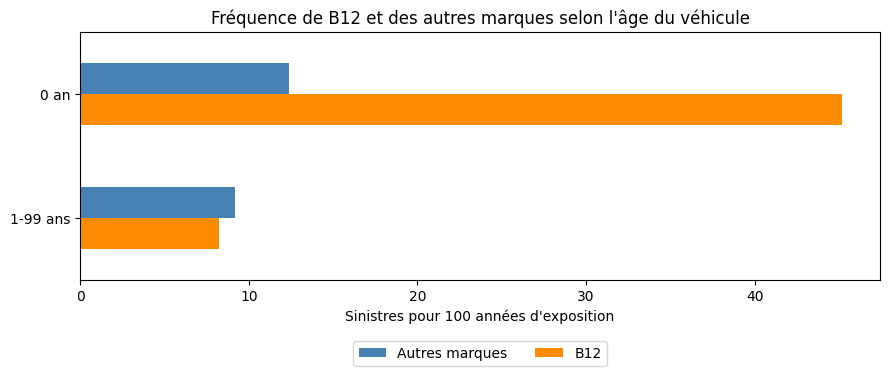

In [8]:
df_marque_vehicule = df_croisements.groupby(
    ['GroupeMarque', 'GroupeVehicule'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_marque_vehicule['Frequence100'] = (
    df_marque_vehicule['NbSinistres'] / df_marque_vehicule['Exposition'] * 100
)
df_marque_vehicule['SansMontantPct'] = (
    df_marque_vehicule['NbSansMontant']
    / df_marque_vehicule['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_marque_vehicule.round(2).to_string(index=False))

# Afficher les deux groupes d'âge dont la signification est connue.
graphique = df_marque_vehicule.loc[
    df_marque_vehicule['GroupeVehicule'] != '100 ans et plus'
]
graphique = graphique.pivot(
    index='GroupeVehicule', columns='GroupeMarque', values='Frequence100'
)
graphique.plot.barh(figsize=(9, 4), color=['steelblue', 'darkorange'])
plt.title("Fréquence de B12 et des autres marques selon l'âge du véhicule")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

**Constat :** pour les véhicules de **0 an**, B12 atteint **45,16** sinistres pour 100 années, contre **12,39** pour les autres marques.
Le groupe **B12 / 0 an** contient **37 069 contrats** et **4 318 sinistres**.
Pour les véhicules de **1 à 99 ans**, B12 est à **8,22**, contre **9,20** pour les autres marques.

L'écart observé sur B12 n'est donc pas uniforme : il se concentre sur les véhicules de 0 an.
De plus, **87,10 %** des contrats sinistrés du groupe B12 / 0 an n'ont aucun montant retrouvé.
Je dois faire vérifier ce périmètre avant de conclure sur ses coûts ou sur un effet propre à la marque.

### 3.1. Quel rôle jouent les durées d'exposition ?

Je regarde ensuite la fréquence des véhicules de 0 an selon leur durée d'exposition, avec les véhicules de 1 à 99 ans comme comparaison.
Les tranches sont en années : « jusqu'à 0,10 an » ne signifie pas une période calendaire observée.

 GroupeVehicule TrancheExposition  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
           0 an   Jusqu’à 0,10 an       22545         1631     1217.77                 1557           1464        133.93           94.03
           0 an      0,10-0,50 an       22396         2116     6343.23                 1993           1518         33.36           76.17
           0 an         0,50-1 an       12614         1451     8951.33                 1365            833         16.21           61.03
           0 an      Plus de 1 an         184            7      206.70                    7              0          3.39            0.00
       1-99 ans   Jusqu’à 0,10 an      105048         1829     6312.28                 1715            589         28.98           34.34
       1-99 ans      0,10-0,50 an      204117         8036    62478.83                 7563           1326         12.86           17.53
       1-99 ans         0,50-1 an      31

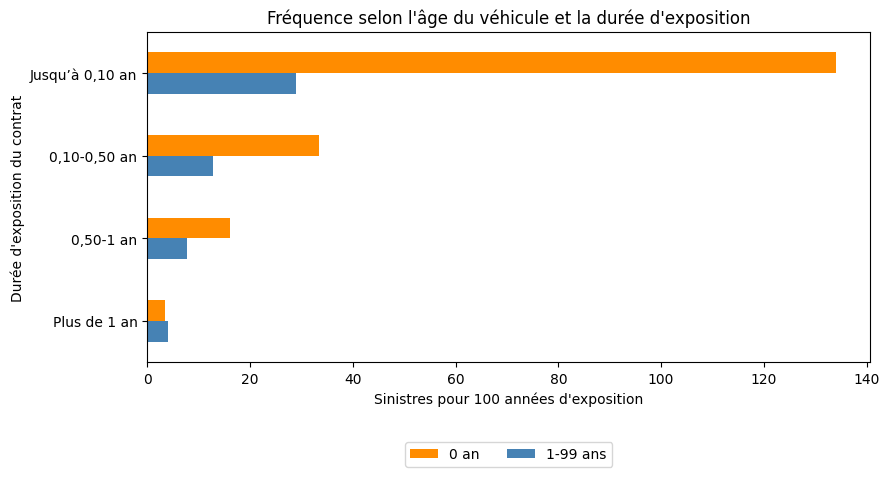

In [9]:
df_vehicule_exposition = df_croisements.groupby(
    ['GroupeVehicule', 'TrancheExposition'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_vehicule_exposition['Frequence100'] = (
    df_vehicule_exposition['NbSinistres'] / df_vehicule_exposition['Exposition'] * 100
)
df_vehicule_exposition['SansMontantPct'] = (
    df_vehicule_exposition['NbSansMontant']
    / df_vehicule_exposition['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_vehicule_exposition.round(2).to_string(index=False))

graphique = df_vehicule_exposition.loc[
    df_vehicule_exposition['GroupeVehicule'] != '100 ans et plus'
]
graphique = graphique.pivot(
    index='TrancheExposition', columns='GroupeVehicule', values='Frequence100'
)
graphique.plot.barh(figsize=(9, 5), color=['darkorange', 'steelblue'])
plt.title("Fréquence selon l'âge du véhicule et la durée d'exposition")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Durée d'exposition du contrat")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Pour les véhicules de **0 an exposés au plus 0,10 année**, la fréquence atteint **133,93**,
avec **22 545 contrats**, **1 631 sinistres** et **1 217,77 années d'exposition cumulées**.
**94,03 %** de leurs contrats sinistrés sont sans montant retrouvé.
Pour les véhicules de 0 an exposés entre **0,50 et 1 an**, la fréquence est de **16,21**.

Une fréquence supérieure à 100 est possible : il s'agit de sinistres rapportés à une durée, pas d'un pourcentage de contrats.
Ce croisement ne prouve pas que la durée cause les sinistres. Il justifie de vérifier que `ClaimNb` et `Exposure`
couvrent bien le même périmètre et la même durée. Je conserve les valeurs d'origine.

## 4. Les 18-24 ans ont-ils une fréquence plus élevée dans chaque tranche de bonus-malus ?

Je compare les 18-24 ans aux 25-99 ans, à tranche de bonus-malus identique.
Cela permet de voir si l'écart global reste le même dans les sous-groupes, sans isoler un effet causal de l'âge.

GroupeConducteur TrancheBonusMalus  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
 100 ans et plus       50 ou moins           3            0        1.73                    0              0          0.00             NaN
       18-24 ans       50 ou moins         972           63      520.94                   61             11         12.09           18.03
       18-24 ans             51-75        1831           74     1035.22                   70              6          7.15            8.57
       18-24 ans            76-100       25006         1760     9861.30                 1620            277         17.85           17.10
       18-24 ans           101-125        2179          416      973.72                  386             27         42.72            6.99
       18-24 ans           126-150         142           32       67.74                   27              0         47.24            0.00
       18-24 ans           151-200

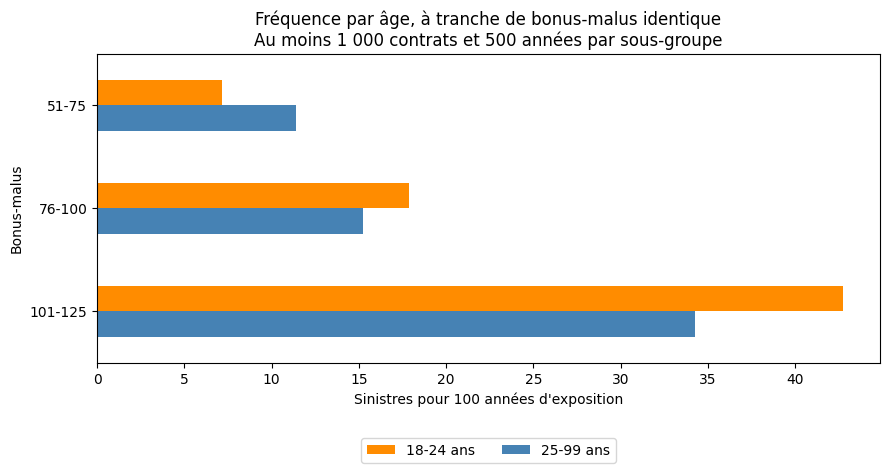

In [10]:
df_age_bonus = df_croisements.groupby(
    ['GroupeConducteur', 'TrancheBonusMalus'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_age_bonus['Frequence100'] = df_age_bonus['NbSinistres'] / df_age_bonus['Exposition'] * 100
df_age_bonus['SansMontantPct'] = (
    df_age_bonus['NbSansMontant'] / df_age_bonus['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_age_bonus.round(2).to_string(index=False))

# Pour le graphique, garder les sous-groupes avec assez de volume pour être lisibles.
# Ces seuils d'affichage ne constituent pas un test statistique.
graphique = df_age_bonus.loc[
    (df_age_bonus['NbContrats'] >= 1000)
    & (df_age_bonus['Exposition'] >= 500)
].copy()
graphique = graphique.pivot(
    index='TrancheBonusMalus', columns='GroupeConducteur', values='Frequence100'
)

# Garder les tranches où les deux groupes d'âge passent les seuils.
graphique = graphique.dropna()
graphique.plot.barh(figsize=(9, 5), color=['darkorange', 'steelblue'])
plt.title("Fréquence par âge, à tranche de bonus-malus identique\nAu moins 1 000 contrats et 500 années par sous-groupe")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Bonus-malus")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Dans la tranche **76-100**, les 18-24 ans sont à **17,85**, contre **15,25** pour les 25-99 ans.
Les effectifs sont respectivement de **25 006** et **86 045 contrats**.
Dans la tranche **101-125**, les fréquences sont de **42,72** et **34,25**, sur des volumes plus faibles.

En revanche, dans la tranche **51-75**, les 18-24 ans sont à **7,15**, contre **11,38** pour les 25-99 ans.
Le premier chiffre repose sur **74 sinistres** : je garde cet effectif visible et je reste prudent sur sa stabilité.

L'écart selon l'âge n'est donc pas identique dans toutes les tranches de bonus-malus.
Les autres caractéristiques, comme le véhicule et la zone, peuvent encore différer entre les groupes.

## 5. R11, zones E/F et forte densité : plusieurs lectures du même contexte ?

Je commence par regarder les densités observées dans chaque zone.
Cela évite de considérer automatiquement la zone et la densité comme deux signaux indépendants.

In [11]:
df_zones = df_croisements.groupby('Area', as_index=False).agg(
    NbContrats=('IDpol', 'count'),
    DensiteMin=('Density', 'min'),
    DensiteMax=('Density', 'max')
)
print(df_zones.to_string(index=False))

Area  NbContrats  DensiteMin  DensiteMax
   A      103957           1          50
   B       75459          50         100
   C      191880         100         500
   D      151596         500        1993
   E      137167        2001        9850
   F       17954       10008       27000


Dans ce fichier, les densités observées sont comprises entre **2 001 et 9 850** pour E,
et entre **10 008 et 27 000** pour F. Ces plages décrivent les données présentes, pas une règle universelle de codification.
Les zones E/F et les tranches de densité élevée se recoupent donc en partie.

Je compare ensuite R11 aux autres régions, à tranche de densité identique.

  GroupeRegion TrancheDensite  NbContrats  NbSinistres  Exposition  NbContratsSinistres  NbSansMontant  Frequence100  SansMontantPct
Autres régions          1-100      176501         8696   103674.30                 8300           2634          8.39           31.73
Autres régions        101-500      185297         9511   101487.47                 9011           2491          9.37           27.64
Autres régions      501-1 000       67849         3751    34782.48                 3477            863         10.78           24.82
Autres régions    1 001-5 000      161870         9119    80185.52                 8569           1648         11.37           19.23
Autres régions   5 001-20 000       16705         1047     8161.03                  990            160         12.83           16.16
           R11          1-100        3088          177     1393.09                  171             66         12.71           38.60
           R11        101-500        6507          363     2923.72   

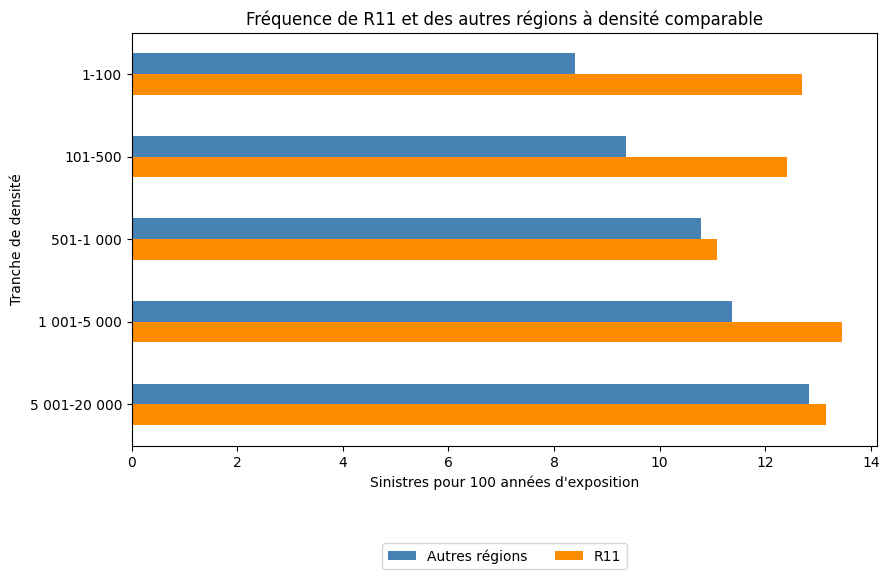

In [12]:
df_region_densite = df_croisements.groupby(
    ['GroupeRegion', 'TrancheDensite'], as_index=False, observed=True
).agg(
    NbContrats=('IDpol', 'count'),
    NbSinistres=('ClaimNb', 'sum'),
    Exposition=('Exposure', 'sum'),
    NbContratsSinistres=('ContratSinistre', 'sum'),
    NbSansMontant=('SansMontant', 'sum')
)
df_region_densite['Frequence100'] = (
    df_region_densite['NbSinistres'] / df_region_densite['Exposition'] * 100
)
df_region_densite['SansMontantPct'] = (
    df_region_densite['NbSansMontant']
    / df_region_densite['NbContratsSinistres'].replace(0, np.nan) * 100
)
print(df_region_densite.round(2).to_string(index=False))

graphique = df_region_densite.pivot(
    index='TrancheDensite', columns='GroupeRegion', values='Frequence100'
)
print("Fréquences comparées, NaN si le groupe n'existe pas :")
print(graphique.round(2))

# Ne pas transformer une absence de groupe de comparaison en fréquence nulle.
# Le graphique garde seulement les tranches présentes des deux côtés.
graphique = graphique.dropna()
graphique.plot.barh(figsize=(9, 6), color=['steelblue', 'darkorange'])
plt.title("Fréquence de R11 et des autres régions à densité comparable")
plt.xlabel("Sinistres pour 100 années d'exposition")
plt.ylabel("Tranche de densité")
plt.gca().invert_yaxis()
plt.legend(title="", loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2)
plt.tight_layout()
plt.show()

Pour la tranche **1 001-5 000**, R11 est à **13,45**, contre **11,37** pour les autres régions.
Pour la tranche **5 001-20 000**, les fréquences sont plus proches : **13,15** et **12,83**.
L'écart régional n'a donc pas la même ampleur selon la densité.

Les **11 302 contrats de densité supérieure à 20 000** sont tous en R11 dans ce fichier.
Je ne dispose donc pas d'un groupe situé ailleurs pour comparer cette tranche.
Le `NaN` du tableau signifie « aucun groupe de comparaison », et non « zéro sinistre ».

Ces résultats ne prouvent pas un effet propre à R11 : les tranches restent larges et les profils des contrats peuvent différer.

## 6. Vérifier que les croisements conservent le portefeuille

Les filtres des graphiques servent uniquement à la lecture.
Les quatre tableaux de croisement gardent tous les contrats, y compris les âges à vérifier et les durées supérieures à un an.

In [13]:
croisements = {
    'Marque et âge du véhicule': df_marque_vehicule,
    'Âge du véhicule et exposition': df_vehicule_exposition,
    'Âge du conducteur et bonus-malus': df_age_bonus,
    'Région et densité': df_region_densite
}

for nom, tableau in croisements.items():
    contrats_ok = tableau['NbContrats'].sum() == nb_contrats
    sinistres_ok = tableau['NbSinistres'].sum() == nb_sinistres_declares
    exposition_ok = round(tableau['Exposition'].sum(), 6) == round(exposition_totale, 6)
    manquants_ok = tableau['NbSansMontant'].sum() == nb_contrats_sans_montant
    print(nom)
    print("Contrats, sinistres, exposition, contrats sinistrés sans montant :")
    print(contrats_ok, sinistres_ok, exposition_ok, manquants_ok)

Marque et âge du véhicule
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Âge du véhicule et exposition
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Âge du conducteur et bonus-malus
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True
Région et densité
Contrats, sinistres, exposition, contrats sinistrés sans montant :
True True True True


## 7. Ce que cette analyse apporte

| Sujet | Ce que montre le croisement | Limite | Suite proposée |
|---|---|---|---|
| B12 et véhicules de 0 an | Fréquence de 45,16 pour B12 / 0 an ; 8,22 pour B12 / 1-99 ans | 87,10 % des contrats sinistrés B12 / 0 an sont sans montant retrouvé | Vérifier en priorité les extractions, la signification des codes et l'alignement entre ClaimNb et Exposure |
| Courtes expositions | Fréquence de 133,93 pour les véhicules de 0 an exposés au plus 0,10 année | 94,03 % des contrats sinistrés de cette case sont sans montant ; la fréquence est annualisée | Confirmer les périodes réellement couvertes avant toute conclusion sur le risque |
| Âge et bonus-malus | Dans la tranche 76-100, fréquence de 17,85 pour les 18-24 ans contre 15,25 pour les 25-99 ans | L'écart n'est pas identique dans toutes les tranches et d'autres profils peuvent différer | Examiner les circonstances des sinistres et les autres caractéristiques avant de proposer une action de prévention |
| Région et densité | L'écart R11 / autres régions dépend de la tranche de densité | Aucun groupe hors R11 au-dessus de 20 000 dans ce fichier | Garder la densité dans les comparaisons et éviter une conclusion régionale unique |

**Ma priorité est d'abord de comprendre le périmètre B12 / véhicules de 0 an**, où fréquence élevée et coûts très incomplets se cumulent.
L'analyse par âge et bonus-malus vient ensuite pour préciser les profils à investiguer.
Les constats géographiques doivent tenir compte de la densité et des groupes réellement comparables.

Les seuils de sélection sont des choix d'exploration. Aucune de ces comparaisons ne démontre une causalité ou ne justifie à elle seule une modification de tarif.
Je conserve les règles de qualité de l'analyse globale : coûts inconnus non remplacés par zéro, valeurs extrêmes conservées et âges de 100 ans signalés.

### Pour le tableau de bord

- L'[analyse globale](analyse_globale.ipynb) fournit les KPI et la vue d'ensemble.
- `df_prioritaires` présente les groupes retenus avec leurs critères, leurs effectifs, leur fréquence et la part de contrats sinistrés sans montant.
- Les quatre tableaux de croisement permettent d'explorer les profils. Les effectifs et l'exposition doivent rester visibles à côté des fréquences.
- Les alertes de qualité restent affichées : une fréquence élevée n'efface pas les limites des données.

## 8. Exporter les données pour Power BI

Je garde deux grains : **une ligne par contrat** dans `contrats.csv` et **une ligne par sinistre observé** dans `sinistres.csv`.
La relation utilisera `IDpol`, du contrat vers ses sinistres. Les fréquences seront calculées depuis les contrats et les coûts depuis les sinistres.

Les orphelins restent dans un fichier séparé, car leurs caractéristiques sont inconnues. `LigneSource` indique la position de la ligne dans `sev` : ce n'est pas un identifiant de sinistre fourni par la source.

Les fichiers sont enregistrés dans `data/processed`, en UTF-8, avec `;` comme séparateur et un point décimal. Les valeurs manquantes restent vides. `controle_kpi.csv` sert de référence pour vérifier Power BI ; je ne l'utilise pas pour calculer les mesures du rapport.

In [14]:
from pathlib import Path

dossier_export = racine / 'data/processed'
dossier_export.mkdir(parents=True, exist_ok=True)

# Garder les caractéristiques et les sinistres déclarés au grain contrat.
# Les montants seront calculés depuis la table des sinistres individuels.
contrats_export = df_croisements.drop(columns=['NbSinister', 'TotalAmount']).copy()

# Conserver l'ordre des tranches dans Power BI.
for colonne in segments_tranches + ['TrancheExposition']:
    contrats_export['Ordre_' + colonne] = contrats_export[colonne].cat.codes + 1

sinistres_export = df_sev_rapprochable.copy()
sinistres_export.insert(0, 'LigneSource', sinistres_export.index + 1)

orphelins_export = df_sev_orphelins.copy()
orphelins_export.insert(0, 'LigneSource', orphelins_export.index + 1)

tables_export = {
    'contrats': contrats_export,
    'sinistres': sinistres_export,
    'orphelins': orphelins_export,
    'controle_kpi': df_kpi
}

for nom, table in tables_export.items():
    table.to_csv(dossier_export / f'{nom}.csv', index=False, sep=';', encoding='utf-8-sig')
    print(nom, ':', len(table), 'lignes exportées')

# Relire les fichiers pour vérifier les clés et les totaux après export.
contrats_relus = pd.read_csv(dossier_export / 'contrats.csv', sep=';')
sinistres_relus = pd.read_csv(dossier_export / 'sinistres.csv', sep=';')
orphelins_relus = pd.read_csv(dossier_export / 'orphelins.csv', sep=';')

assert len(contrats_relus) == nb_contrats
assert contrats_relus['IDpol'].is_unique
assert contrats_relus['ClaimNb'].sum() == nb_sinistres_declares
assert np.isclose(contrats_relus['Exposure'].sum(), exposition_totale)
assert sinistres_relus['IDpol'].isin(contrats_relus['IDpol']).all()
assert not orphelins_relus['IDpol'].isin(contrats_relus['IDpol']).any()
assert len(sinistres_relus) == nb_sinistres_observes
assert round(sinistres_relus['ClaimAmount'].sum(), 2) == round(montant_observe, 2)
assert len(sinistres_relus) + len(orphelins_relus) == len(df_sev)
assert round(sinistres_relus['ClaimAmount'].sum() + orphelins_relus['ClaimAmount'].sum(), 2) == round(df_sev['ClaimAmount'].sum(), 2)

print('Contrôles des exports : OK')

contrats : 678013 lignes exportées
sinistres : 26444 lignes exportées
orphelins : 195 lignes exportées
controle_kpi : 1 lignes exportées


Contrôles des exports : OK
